# Capstone Two — Exploratory Data Analysis

## Predictive Healthcare Operations & Capacity Analytics

This notebook performs the Exploratory Data Analysis (EDA) required for Springboard Capstone Two.

### EDA goals
1. Understand the structure and quality of the dataset.
2. Examine the target variable, `DIS_TOT`.
3. Investigate numerical and categorical features.
4. Examine relationships between capacity/utilization variables and the target.
5. Use Pearson correlation and multicollinearity analysis to support feature selection.
6. Investigate missing values and outliers.
7. Identify potential target leakage.
8. Create a small number of useful engineered features.
9. Document a candidate feature set for the modeling stage.

**Important:** EDA supports feature-selection decisions, but the final feature set should be confirmed during modeling and validation.

## 1. Load the Processed Dataset

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Plotting settings
sns.set_theme(style="whitegrid")

# Path to the processed HCAI hospital dataset.
DATA_PATH = Path("../data/processed/hcai_hospital_data_clean.csv")

# Load the dataset.
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (9179, 159)


## 2. Dataset Overview

This section checks dimensions, data types, reporting periods, facilities, duplicates, and unique values.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData types:")
display(df.dtypes.value_counts())

print("\nFirst five rows:")
display(df.head())

Number of rows: 9179
Number of columns: 159

Data types:


int64      106
float64     39
object      14
Name: count, dtype: int64


First five rows:


,FAC_NO,FAC_NAME,YEAR_QTR,BEG_DATE,END_DATE,OP_STATUS,COUNTY_NAME,HSA,HFPA,TYPE_CNTRL,TYPE_HOSP,TEACH_RURL,PHONE,ADDRESS,CITY,ZIP_CODE,CEO,LIC_BEDS,AVL_BEDS,STF_BEDS,DIS_MCAR,DIS_MCAR_MC,DIS_MCAL,DIS_MCAL_MC,DIS_CNTY,DIS_CNTY_MC,DIS_THRD,DIS_THRD_MC,DIS_INDGNT,DIS_OTH,DIS_TOT,DIS_LTC,DAY_MCAR,DAY_MCAR_MC,DAY_MCAL,DAY_MCAL_MC,DAY_CNTY,DAY_CNTY_MC,DAY_THRD,DAY_THRD_MC,DAY_INDGNT,DAY_OTH,DAY_TOT,DAY_LTC,VIS_MCAR,VIS_MCAR_MC,VIS_MCAL,VIS_MCAL_MC,VIS_CNTY,VIS_CNTY_MC,VIS_THRD,VIS_THRD_MC,VIS_INDGNT,VIS_OTH,VIS_TOT,GRIP_MCAR,GRIP_MCAR_MC,GRIP_MCAL,GRIP_MCAL_MC,GRIP_CNTY,GRIP_CNTY_MC,GRIP_THRD,GRIP_THRD_MC,GRIP_INDGNT,GRIP_OTH,GRIP_TOT,GROP_MCAR,GROP_MCAR_MC,GROP_MCAL,GROP_MCAL_MC,GROP_CNTY,GROP_CNTY_MC,GROP_THRD,GROP_THRD_MC,GROP_INDGNT,GROP_OTH,GROP_TOT,BAD_DEBT,CADJ_MCAR,CADJ_MCAR_MC,CADJ_MCAL,CADJ_MCAL_MC,DISP_855,CADJ_CNTY,CADJ_CNTY_MC,CADJ_THRD,CADJ_THRD_MC,CHAR_HB,CHAR_OTH,SUB_INDGNT,TCH_ALLOW,TCH_SUPP,DED_OTH,DED_TOT,CAP_MCAR,CAP_MCAL,CAP_CNTY,CAP_THRD,CAP_TOT,NET_MCAR,NET_MCAR_MC,NET_MCAL,NET_MCAL_MC,NET_CNTY,NET_CNTY_MC,NET_THRD,NET_THRD_MC,NET_INDGNT,NET_OTH,NET_TOT,OTH_OP_REV,TOT_OP_EXP,PHY_COMP,NONOP_REV,DIS_PIPS,DAY_PIPS,EXP_PIPS,EXP_POPS,CAP_EXP,FIX_ASSETS,DISP_TRNFR,DIS_TOT_CC,PAT_DAY_TOT_CC,TOT_OUT_VIS_CC,GROS_INPAT_REV_CC,GROS_OUTPAT_REV_CC,CONTR_ADJ_CC,OTHR_DEDUCT_CC,CAP_PREM_REV_CC,NET_PAT_REV_CC,QA_FEES,QA_SUPPL_PAY,MNGD_CARE_QA_PAY,DEP_AMORT_EXP_OPS,CASH,MARKETABLE_SEC,OTH_CURR_ASSETS,TOT_CURR_ASSETS,LIMITED_USE_CASH,LIMITED_USE_INV,LIMITED_USE_OTHER_ASSETS,TOT_LIMITED_USE_ASSETS,TOT_PPE,ACCU_DEP_AMORT,NET_TOT_PPE,CONST_IN_PROGRESS,TOT_INV_AND_OTH_ASSETS,TOT_INTANGIBLE_ASSETS,TOT_ASSETS,CURR_LIABILITIES,CURR_MAT_LT_DEBT,TOT_CURR_LIABILITIES,TOT_DEF_CREDITS,TOT_LT_DEBT,CURR_MATURITIES,NET_TOT_LT_DEBT,TOT_LIABILITIES,TOT_EQUITY,TOT_LIABILITY_AND EQUITY
0,106580996,ADVENTIST HEALTH AND RIDEOUT,20211,2021-01-01,2021-03-31,Open,Yuba,02 - Golden Empire,227,Non Profit Corp.,Comparable,NaN,530-749-4663,726 FOURTH ST,MARYSVILLE,95901,RICK RAWSON,221,221,185,811,186,164,1185,0,0,0,489,0,33,2868,0,3646,880,1271,8148,0,0,0,2154,0,157,16256,0,11313,1645,1661,15191,0,0,2734,7911,0,3276,43731,153232128,21311728,20282308,68693370,0,0,0,53699088,0,2105708,319324330,52970567,5726303,6806305,40600360,0,0,2058123,33444843,0,3403582,145010083,2666388,161249005,14670643,19080334,101116562,0,0,0,678333,44184127,0,2842566,0,0,0,3958689,350446647,0,0,0,0,0,44296689,12264567,7587394,8160436,0,0,501393,40425126,0,652161,113887766,2051738,128266608,0,75820,0,0,0,0,1686777,"318,254,966.000",0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,106150788,ADVENTIST HEALTH BAKERSFIELD,20211,2021-01-01,2021-03-31,Open,Kern,09 - Central,617,Non Profit Corp.,Comparable,NaN,661-395-3000,2615 CHESTER AVENUE,BAKERSFIELD,93301,SHARLET BRIGGS,254,254,197,696,851,173,772,0,0,251,964,0,14,3721,0,3751,3778,1205,3004,0,0,1480,4031,0,112,17361,0,12764,3932,1315,11424,0,0,5558,15592,0,1049,51634,78830087,85319575,18988853,66044326,0,0,29055733,89898131,0,1935857,370072562,46007280,33222211,4322872,53067097,0,0,14299424,67270111,0,4307177,222496172,2463652,104649244,100017020,17212027,95386197,0,0,0,29719714,116121372,0,697227,0,0,0,11115806,477382259,0,0,0,0,0,19266922,18177109,6373352,23392349,0,0,8718750,38622232,0,635761,115186475,11018173,112548197,0,1183364,0,0,0,0,6309689,"163,295,784.000",0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,106171049,ADVENTIST HEALTH CLEARLAKE,20211,2021-01-01,2021-03-31,Open,Lake,01 - Northern California,115,Non Profit Corp.,Comparable,Rural,707-995-5820,15630 18TH AVE,CLEARLAKE,95422,DAVID SANTOS,25,25,19,147,18,19,106,0,0,7,28,0,1,326,0,697,86,62,397,0,0,34,104,0,2,1382,0,36759,1946,8390,31076,0,0,10900,5139,0,1804,96014,11432241,1634602,513667,6690879,0,0,282398,16

In [3]:
# Reporting periods
print("Reporting periods:")
display(
    df["YEAR_QTR"]
    .value_counts()
    .sort_index()
    .rename_axis("YEAR_QTR")
    .reset_index(name="Rows")
)

print("Number of reporting periods:", df["YEAR_QTR"].nunique())
print("Number of facilities:", df["FAC_NO"].nunique())

Reporting periods:


,YEAR_QTR,Rows
0,20211,433
1,20212,435
2,20213,436
3,20214,436
4,20221,438
5,20222,439
6,20223,438
7,20224,437
8,20231,436
9,20232,439


Number of reporting periods: 21
Number of facilities: 461


In [4]:
# Check for duplicate rows.
duplicate_rows = df.duplicated().sum()

# Check for duplicate facility-quarter combinations.
duplicate_facility_quarter = df.duplicated(
    subset=["FAC_NO", "YEAR_QTR"]
).sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate FAC_NO + YEAR_QTR combinations:", duplicate_facility_quarter)

Duplicate rows: 0
Duplicate FAC_NO + YEAR_QTR combinations: 0


### Data-quality interpretation

Each observation represents a facility-quarter record. Duplicate facility-quarter records would be problematic because the same hospital and reporting period should not appear more than once.

The duplicate checks above are therefore part of the EDA quality assessment.

## 3. Feature Profile

This table provides a systematic profile of all dataset attributes, including data type, missing values, unique values, and zero values for numerical variables. It provides an initial assessment of data quality and helps identify characteristics that should be considered in the subsequent EDA.

In [5]:
# Create a profile of all dataset features.
# The profile summarizes data type, missing values,
# unique values, and zero values for numerical features.

feature_profile = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Count": df.isna().sum(),
    "Missing_%": df.isna().mean() * 100,
    "Unique_Count": df.nunique(dropna=True),
})

feature_profile["Zero_Count"] = [
    (df[column] == 0).sum()
    if pd.api.types.is_numeric_dtype(df[column])
    else np.nan
    for column in df.columns
]

feature_profile = feature_profile.sort_values(
    "Missing_%",
    ascending=False
)

display(feature_profile)

,Data_Type,Missing_Count,Missing_%,Unique_Count,Zero_Count
TEACH_RURL,object,7148,77.873,2,NaN
CASH,float64,5249,57.185,2532,"1,129.000"
TOT_LIABILITY_AND EQUITY,float64,5246,57.152,3486,436.000
TOT_INV_AND_OTH_ASSETS,float64,5246,57.152,2424,"1,243.000"
DEP_AMORT_EXP_OPS,float64,5246,57.152,3594,177.000
...,...,...,...,...,...
GRIP_MCAR,int64,0,0.000,8258,905.000
GRIP_MCAR_MC,int64,0,0.000,7410,"1,765.000"
GRIP_MCAL,int64,0,0.000,7811,"1,357.000"
GRIP_MCAL_MC,int64,0,0.000,7412,"1,757.000"


In [6]:
print("Features with missing values:")
display(
    feature_profile[
        feature_profile["Missing_Count"] > 0
    ].head(30)
)

Features with missing values:


,Data_Type,Missing_Count,Missing_%,Unique_Count,Zero_Count
TEACH_RURL,object,7148,77.873,2,NaN
CASH,float64,5249,57.185,2532,"1,129.000"
TOT_LIABILITY_AND EQUITY,float64,5246,57.152,3486,436.000
TOT_INV_AND_OTH_ASSETS,float64,5246,57.152,2424,"1,243.000"
DEP_AMORT_EXP_OPS,float64,5246,57.152,3594,177.000
MARKETABLE_SEC,float64,5246,57.152,486,"3,400.000"
OTH_CURR_ASSETS,float64,5246,57.152,3467,444.000
TOT_CURR_ASSETS,float64,5246,57.152,3469,447.000
LIMITED_USE_CASH,float64,5246,57.152,406,"3,453.000"
LIMITED_USE_INV,float64,5246,57.152,603,"3,308.000"


In [7]:
# Numerical and categorical feature lists.
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)

Number of numeric features: 145
Number of categorical features: 14

Categorical features:
['FAC_NAME', 'BEG_DATE', 'END_DATE', 'OP_STATUS', 'COUNTY_NAME', 'HSA', 'TYPE_CNTRL', 'TYPE_HOSP', 'TEACH_RURL', 'PHONE', 'ADDRESS', 'CITY', 'ZIP_CODE', 'CEO']


## 4. Target Variable Analysis

The working target is `DIS_TOT`, total discharges.

The target is examined before analyzing predictors to understand its distribution, scale, missing values, potential outliers, and variation over time.

### 4.1 Target Statistics

In [8]:
TARGET = "DIS_TOT"

if TARGET not in df.columns:
    raise KeyError(f"{TARGET} was not found in the dataset.")

target = df[TARGET]

print("Target:", TARGET)
print("Missing target values:", target.isna().sum())
print("Number of non-missing target values:", target.notna().sum())

display(target.describe())

Target: DIS_TOT
Missing target values: 0
Number of non-missing target values: 9179


count    9,179.000
mean     1,912.889
std      2,123.839
min          0.000
25%        242.000
50%      1,057.000
75%      2,948.000
max     16,454.000
Name: DIS_TOT, dtype: float64

### 4.2 Target Distribution and Outliers

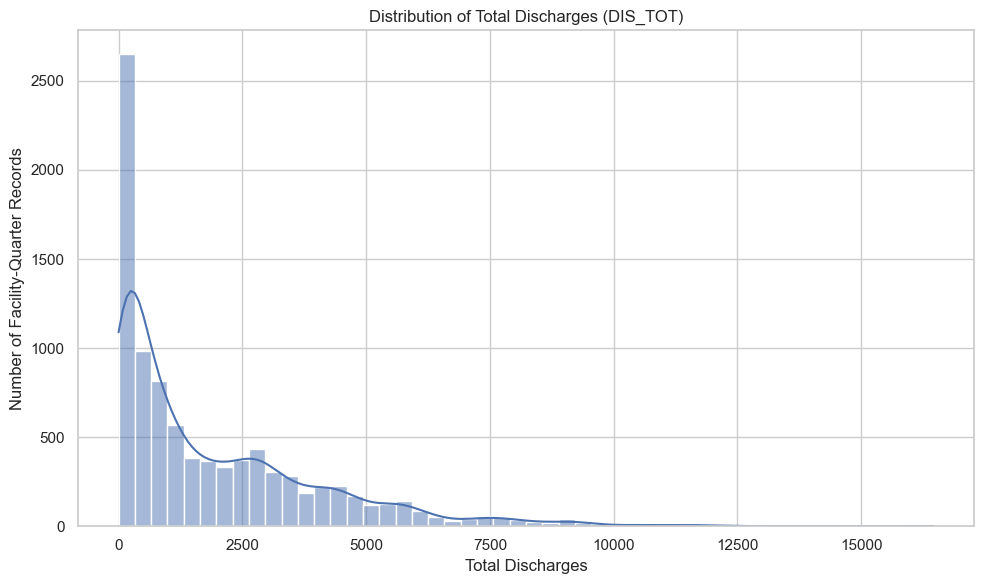

In [9]:
# Target distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x=TARGET,
    bins=50,
    kde=True
)

plt.title("Distribution of Total Discharges (DIS_TOT)")
plt.xlabel("Total Discharges")
plt.ylabel("Number of Facility-Quarter Records")
plt.tight_layout()
plt.show()

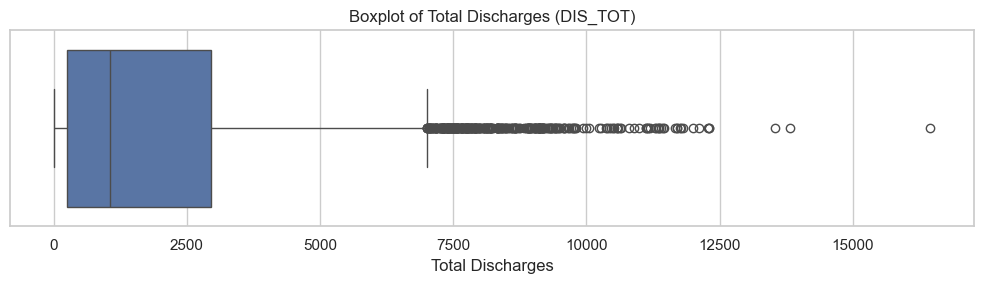

In [10]:
# Boxplot for target outliers
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=df[TARGET]
)

plt.title("Boxplot of Total Discharges (DIS_TOT)")
plt.xlabel("Total Discharges")
plt.tight_layout()
plt.show()

In [11]:
# Calculate the IQR for DIS_TOT.
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1

# Define the IQR outlier boundaries.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify potential outliers.
target_outliers = target[
    (target < lower_bound) | (target > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of IQR outliers:", target_outliers.count())
print("Percent of records:",
      target_outliers.count() / target.notna().sum() * 100)

Q1: 242.0
Q3: 2948.0
IQR: 2706.0
Lower bound: -3817.0
Upper bound: 7007.0
Number of IQR outliers: 322
Percent of records: 3.5080074082144024


### Target Distribution and Outliers

`DIS_TOT` shows substantial variability across facility-quarter observations. The IQR method identified 322 potential outliers, representing 3.51% of non-missing target observations. The upper IQR boundary is 7,007 discharges, while the lower boundary is negative and therefore not meaningful for this non-negative count variable. The potential high-value observations will be retained because unusually high discharge counts may represent legitimate high-volume hospitals rather than data-quality errors.

The time-based summary also shows that the mean number of discharges generally increased over the study period, from 1,756.8 in 2021 Q1 to 2,039.5 in 2026 Q1. The median remained substantially lower than the mean, which is consistent with a right-skewed target distribution.

### 4.3 Target Trends Over Time

In [12]:
# Summarize the target by reporting period.
target_by_period = (
    df.groupby("YEAR_QTR")[TARGET]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(target_by_period)

,YEAR_QTR,count,mean,median
0,20211,433,"1,756.762","1,039.000"
1,20212,435,"1,851.083","1,055.000"
2,20213,436,"1,902.615","1,055.500"
3,20214,436,"1,869.523","1,046.000"
4,20221,438,"1,835.082","1,033.500"
5,20222,439,"1,839.107","1,026.000"
6,20223,438,"1,873.740","1,049.000"
7,20224,437,"1,917.405","1,047.000"
8,20231,436,"1,889.154","1,061.000"
9,20232,439,"1,867.911","1,022.000"


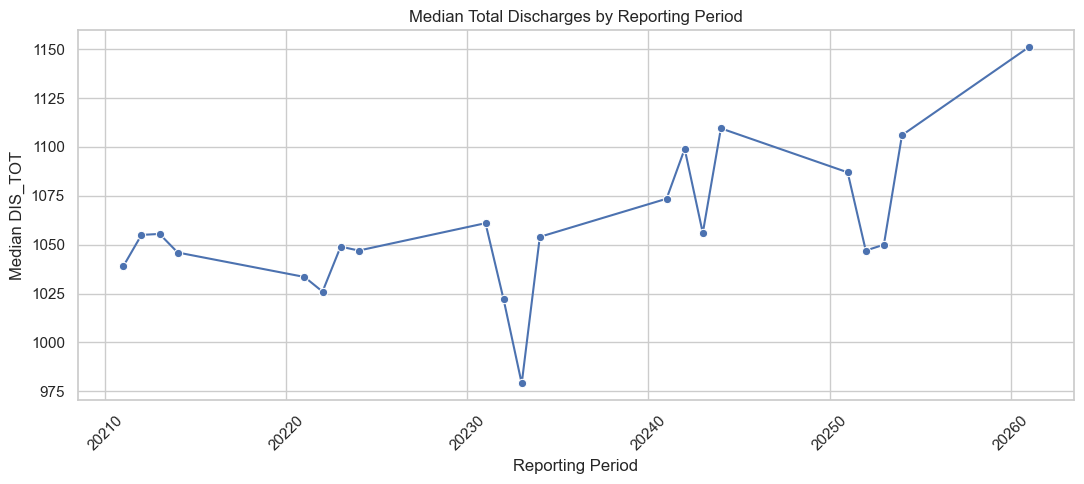

In [13]:
plt.figure(figsize=(11, 5))

sns.lineplot(
    data=target_by_period,
    x="YEAR_QTR",
    y="median",
    marker="o"
)

plt.title("Median Total Discharges by Reporting Period")
plt.xlabel("Reporting Period")
plt.ylabel("Median DIS_TOT")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The time-based summary shows that the mean number of discharges generally increased over the study period, from 1,756.8 in 2021 Q1 to 2,039.5 in 2026 Q1. The median remained substantially lower than the mean, which is consistent with a right-skewed target distribution.

## 5. Univariate Feature Analysis

Every feature is reviewed using appropriate statistics and/or visualizations to:

1. Understand distributions — descriptive statistics, skewness, and histograms for important numerical variables.
2. Understand categorical features — categories, frequencies, and bar charts where appropriate.
3. Identify data characteristics/problems — skewness, extreme values, missing values, rare categories, and variables that may not be useful predictors.

Identifier and contact fields are not treated as meaningful predictive variables.

### 5.1 Numerical Feature Summary

In [14]:
# Descriptive statistics for all numerical features.
numeric_summary = df[numeric_features].describe().T

numeric_summary["missing_%"] = (
    df[numeric_features].isna().mean() * 100
)

numeric_summary["skewness"] = (
    df[numeric_features].skew()
)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,missing_%,skewness
FAC_NO,"9,179.000","106,284,897.227","135,962.076","106,010,735.000","106,190,385.000","106,301,283.000","106,374,049.000","106,580,996.000",0.000,-0.001
YEAR_QTR,"9,179.000","20,233.873",15.105,"20,211.000","20,222.000","20,233.000","20,244.000","20,261.000",0.000,0.049
HFPA,"9,179.000",735.879,351.659,101.000,421.000,807.000,935.000,"1,424.000",0.000,0.100
LIC_BEDS,"9,179.000",219.515,223.562,0.000,66.500,152.000,317.500,"1,500.000",0.000,2.390
AVL_BEDS,"9,179.000",205.258,202.601,0.000,62.000,148.000,291.000,"1,459.000",0.000,2.268
...,...,...,...,...,...,...,...,...,...,...
CURR_MATURITIES,"3,933.000","9,954,144.043","92,596,202.319","-53,216,711.000",0.000,"361,611.000","2,757,050.000","2,268,088,363.000",57.152,20.335
NET_TOT_LT_DEBT,"3,933.000","152,895,869.241","537,425,377.860","-522,035,790.000","9,457.000","10,929,620.000","90,908,858.000","8,007,294,333.000",57.152,8.473
TOT_LIABILITIES,"3,933.000","377,202,575.095","1,195,523,590.027","-507,953,682.000","9,340,785.000","67,728,926.000","251,085,806.000","13,217,668,277.000",57.152,6.216
TOT_EQUITY,"3,933.000","319,792,047.403","1,523,779,849.014","-1,630,120,749.000",0.000,"33,561,735.000","245,458,374.000","23,319,431,833.000",57.152,10.393


### 5.2 Numerical Feature Distributions

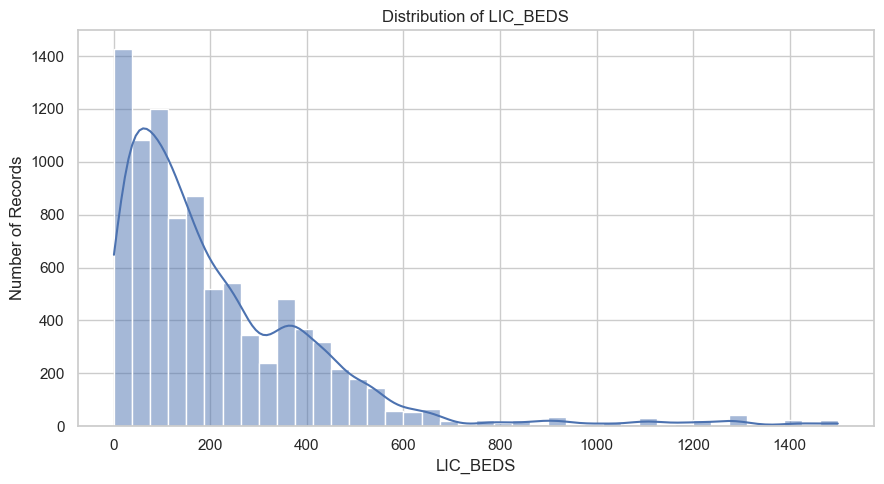

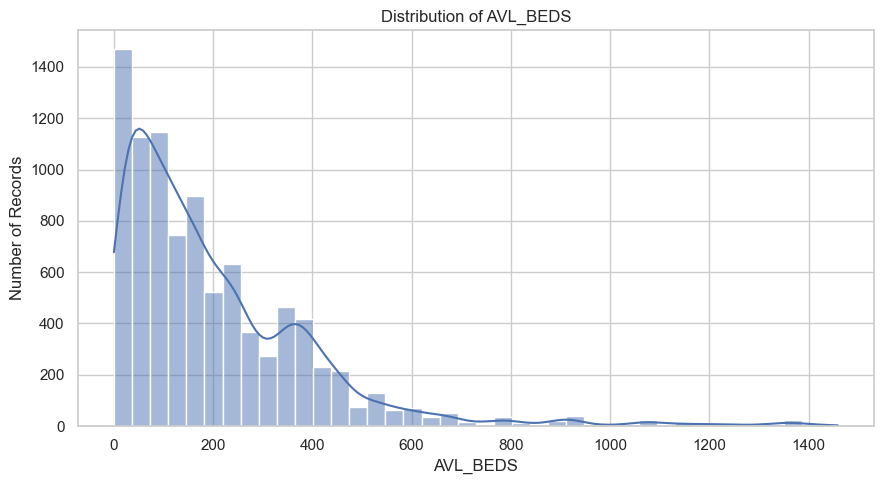

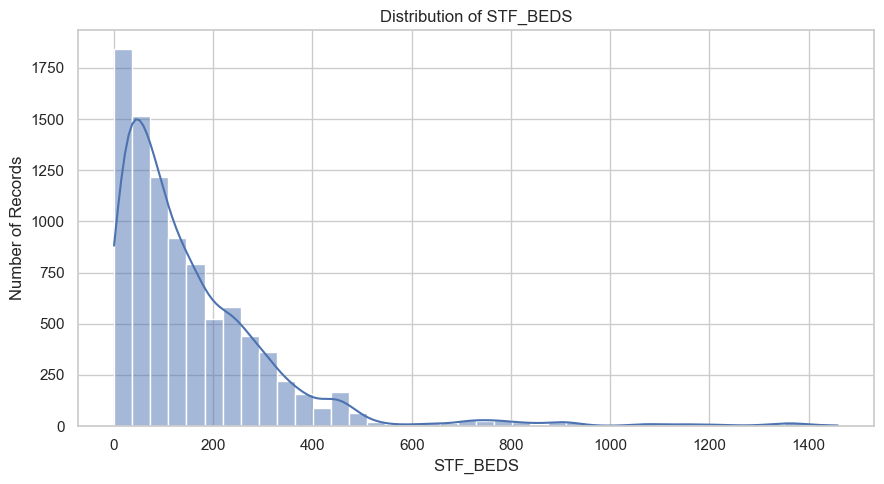

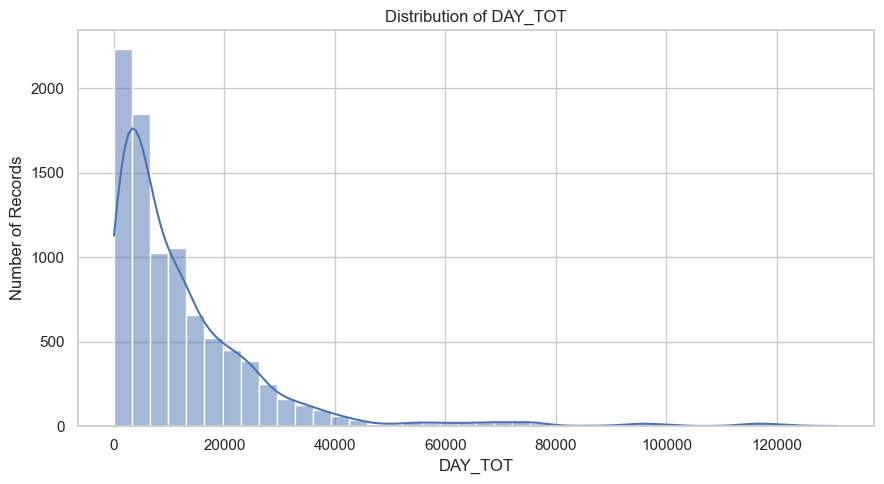

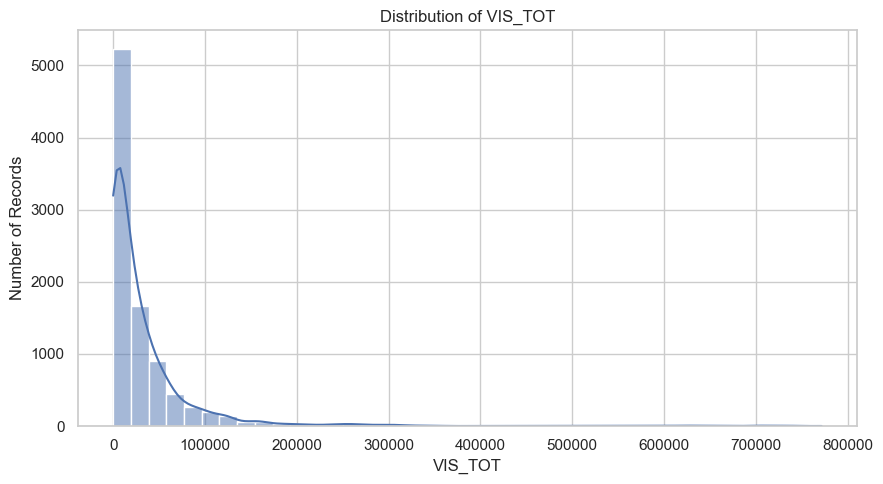

In [34]:
# Plot distributions for the main operational/capacity variables.
capacity_features = [
    feature for feature in [
        "LIC_BEDS",
        "AVL_BEDS",
        "STF_BEDS",
        "DAY_TOT",
        "VIS_TOT"
    ]
    if feature in df.columns
]

for feature in capacity_features:
    plt.figure(figsize=(9, 5))

    sns.histplot(
        data=df,
        x=feature,
        bins=40,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Records")
    plt.tight_layout()
    plt.show()

### 5.3 Categorical Feature Distributions

In [16]:
# Categorical feature frequency tables.
for feature in categorical_features:
    print(f"\n===== {feature} =====")
    display(
        df[feature]
        .value_counts(dropna=False)
        .head(15)
        .rename_axis(feature)
        .reset_index(name="Count")
    )


===== FAC_NAME =====


,FAC_NAME,Count
0,PROVIDENCE ST. JOSEPH HOSPITAL,22
1,LANGLEY PORTER PSYCHIATRIC INSTITUTE,22
2,ENCOMPASS HEALTH REHABILITATION HOSPITAL OF TU...,22
3,ADVENTIST HEALTH AND RIDEOUT,21
4,PORTERVILLE STATE HOSPITAL,21
5,PIONEERS MEMORIAL HEALTHCARE DISTRICT,21
6,PETALUMA VALLEY HOSPITAL,21
7,PATTON STATE HOSPITAL,21
8,PARADISE VALLEY HOSPITAL,21
9,PALMDALE REGIONAL MEDICAL CENTER,21



===== BEG_DATE =====


,BEG_DATE,Count
0,2022-04-01,439
1,2023-04-01,439
2,2023-07-01,439
3,2025-01-01,439
4,2023-10-01,439
5,2024-01-01,438
6,2022-01-01,438
7,2022-07-01,438
8,2024-04-01,437
9,2025-07-01,437



===== END_DATE =====


...

,CITY,Count
0,LOS ANGELES,481
1,SACRAMENTO,309
2,SAN DIEGO,240
3,SAN FRANCISCO,232
4,BAKERSFIELD,206
5,LONG BEACH,151
6,FRESNO,142
7,OAKLAND,135
8,SAN JOSE,122
9,TORRANCE,105



===== ZIP_CODE =====


,ZIP_CODE,Count
0,96001,101
1,95817,84
2,90806,84
3,92270,63
4,90027,63
5,94589,63
6,95823,63
7,94609,63
8,90033,63
9,93301,63



===== CEO =====


,CEO,Count
0,CARRIE PLIETZ,429
1,MICHELLE GASKILL-HAMES,176
2,ANNE BAKAR,152
3,MARIA STEFANOU,133
4,PETER BARONOFF,126
5,JULIE MILLER-PHIPPS,96
6,GARRY OLNEY,59
7,TIM HAYDOCK,57
8,CARL ETTER,55
9,ARNE HYSON,51


### 5.4 Categorical Feature Visualizations

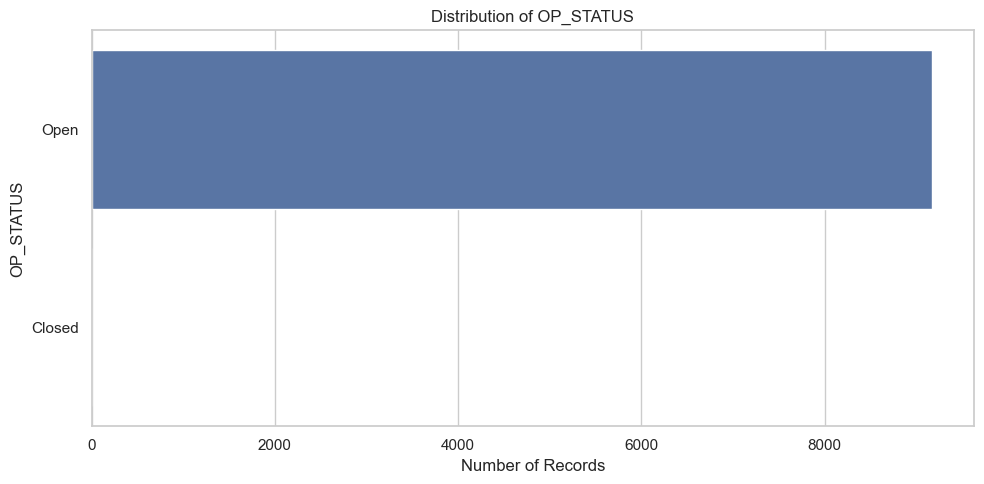

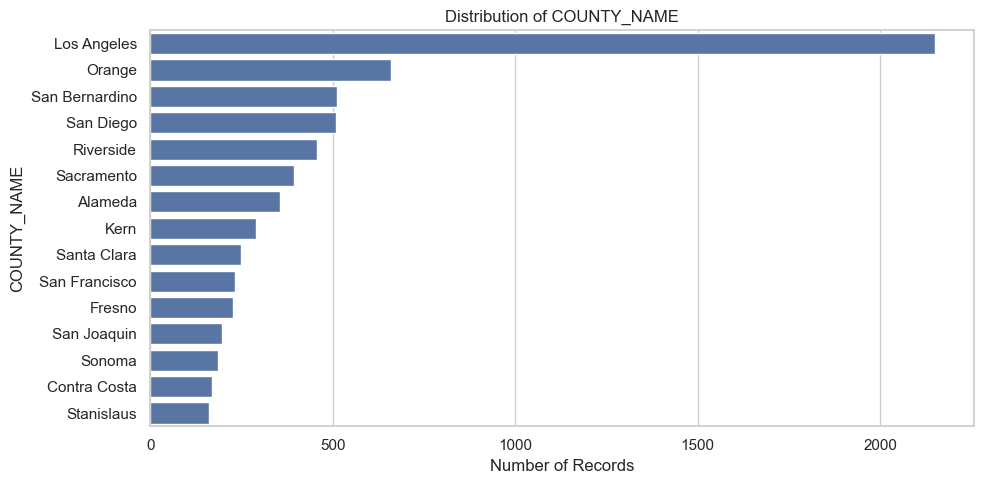

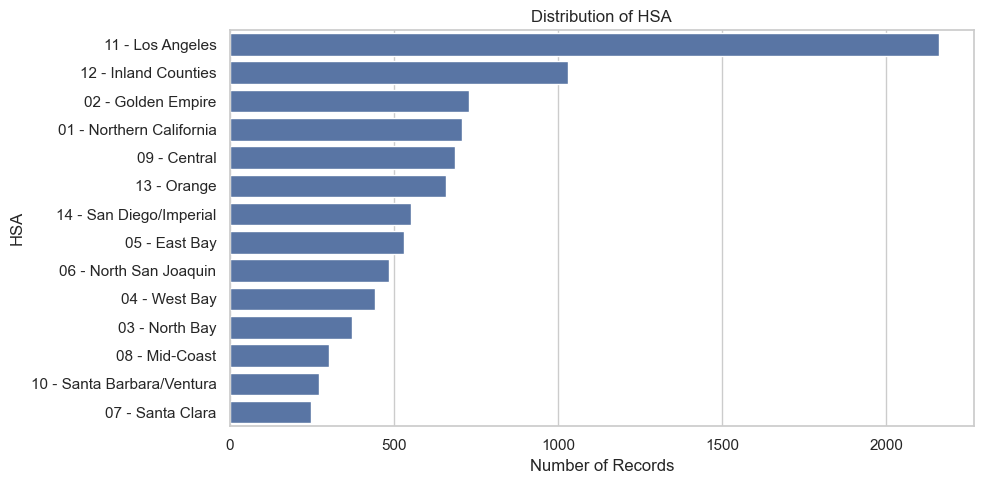

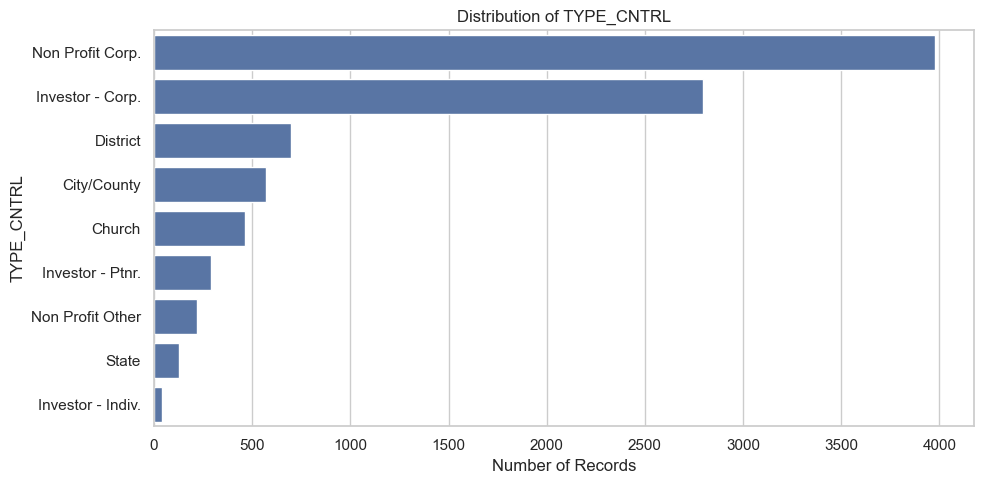

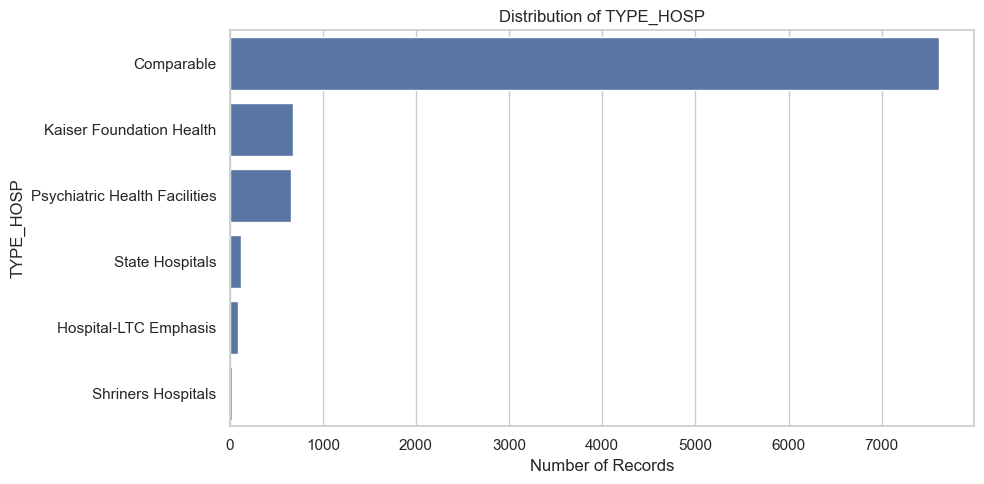

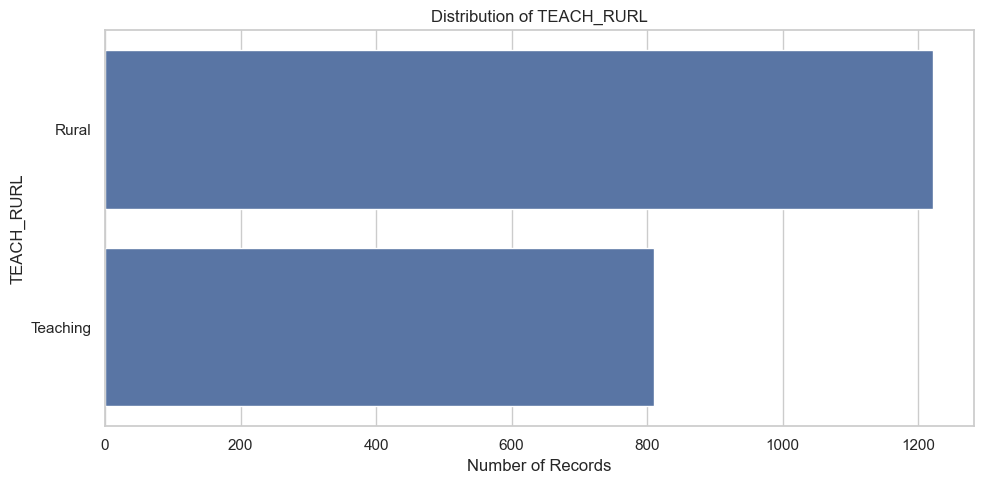

In [17]:
# Bar charts for useful low/moderate-cardinality categorical variables.
categorical_plot_features = [
    feature for feature in [
        "OP_STATUS",
        "COUNTY_NAME",
        "HSA",
        "TYPE_CNTRL",
        "TYPE_HOSP",
        "TEACH_RURL"
    ]
    if feature in df.columns
]

for feature in categorical_plot_features:
    plt.figure(figsize=(10, 5))

    order = df[feature].value_counts().head(15).index

    sns.countplot(
        data=df,
        y=feature,
        order=order
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel("Number of Records")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

## 6. Relationship Analysis

The main project question concerns healthcare operations and capacity. Relationships between `DIS_TOT` and selected capacity and utilization variables are examined using scatterplots, while differences in `DIS_TOT` across selected categorical variables are examined using boxplots.

The analysis focuses on the most relevant variables rather than creating repetitive plots for every feature. These visualizations help identify potential associations, trends, differences between groups, outliers, and variables that may be useful for predicting healthcare utilization.

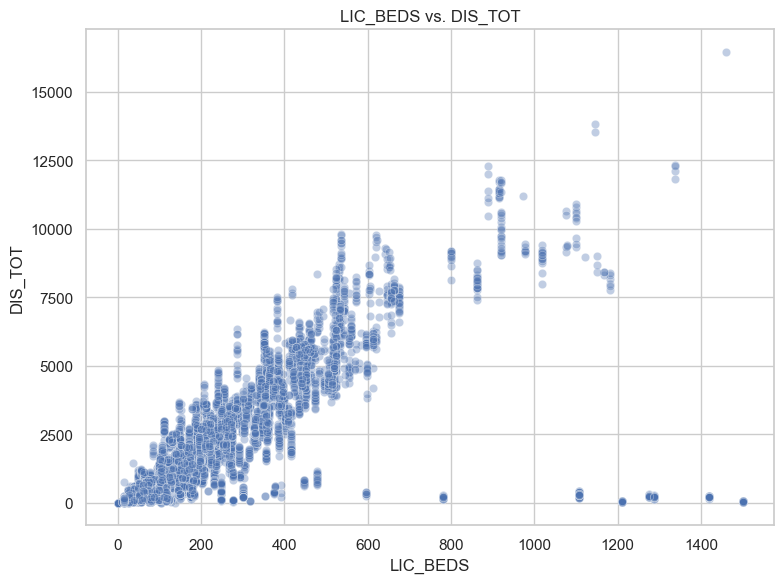

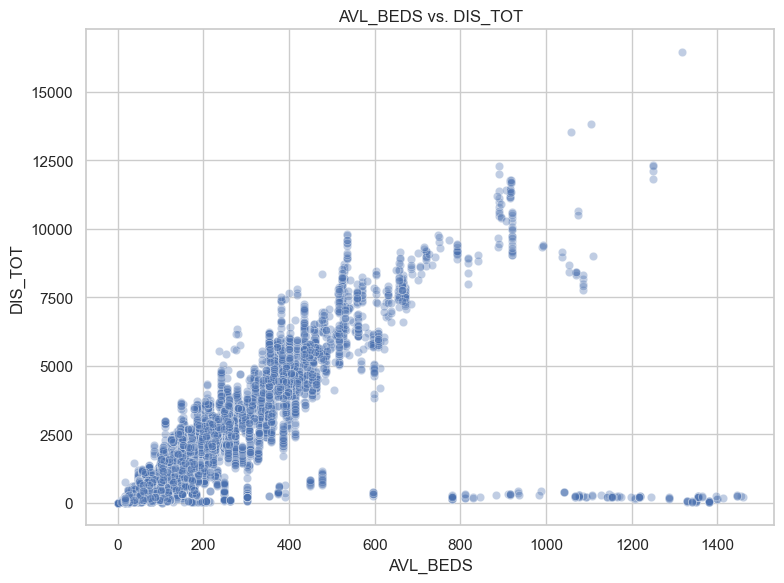

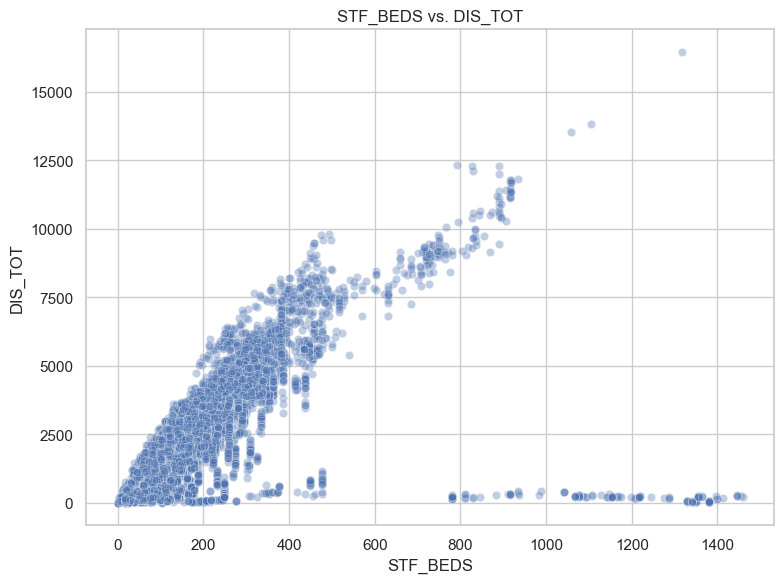

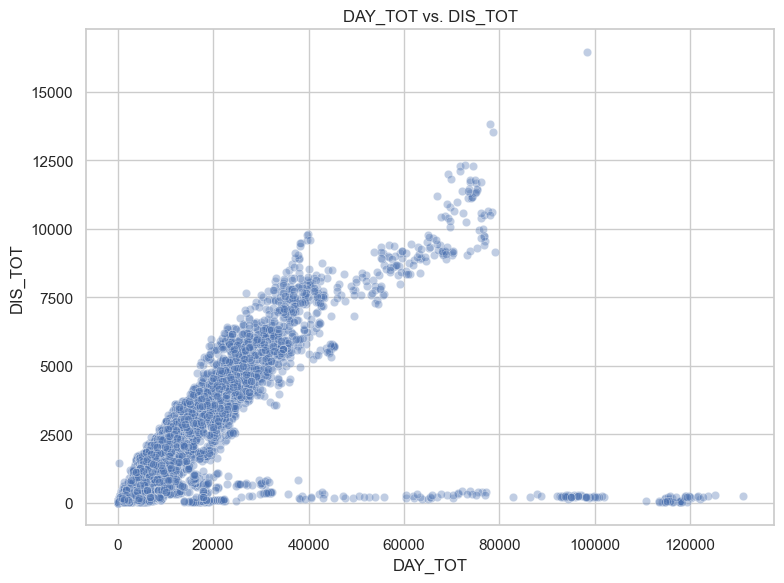

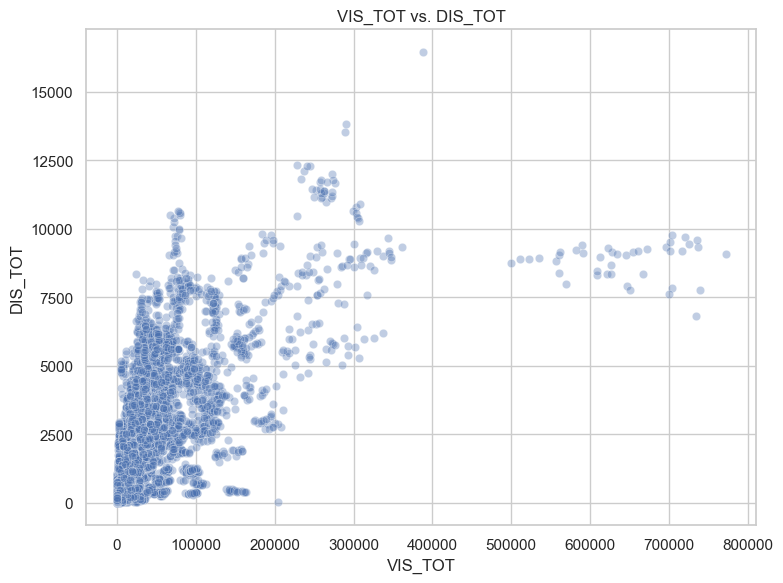

In [18]:
relationship_features = [
    feature for feature in [
        "LIC_BEDS",
        "AVL_BEDS",
        "STF_BEDS",
        "DAY_TOT",
        "VIS_TOT"
    ]
    if feature in df.columns
]

for feature in relationship_features:
    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=df,
        x=feature,
        y=TARGET,
        alpha=0.35
    )

    plt.title(f"{feature} vs. {TARGET}")
    plt.xlabel(feature)
    plt.ylabel(TARGET)
    plt.tight_layout()
    plt.show()

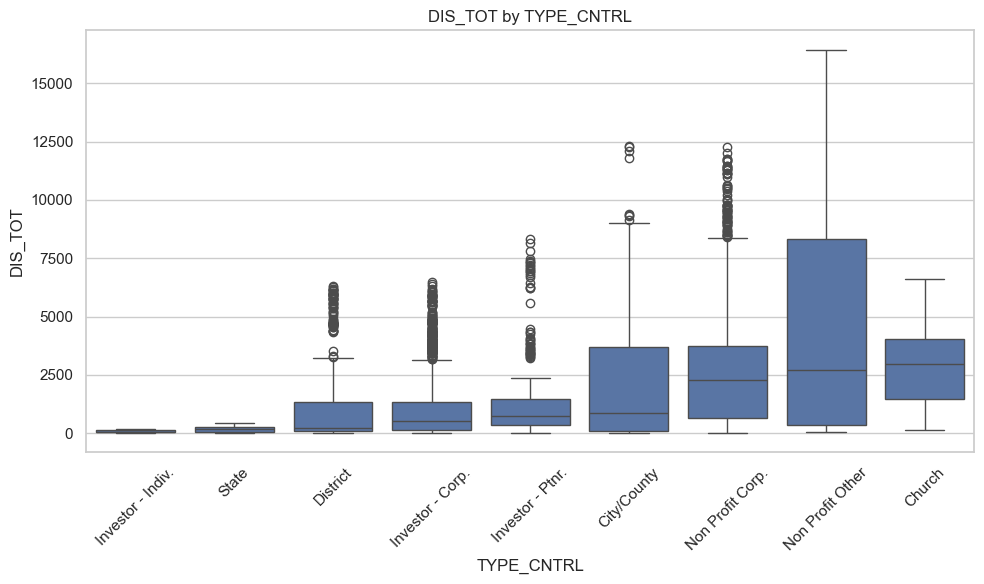

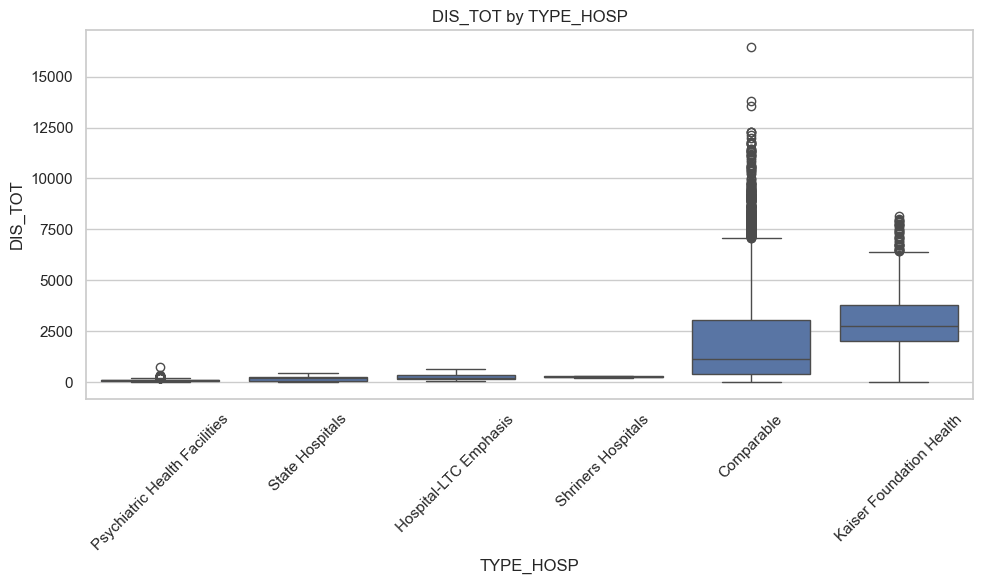

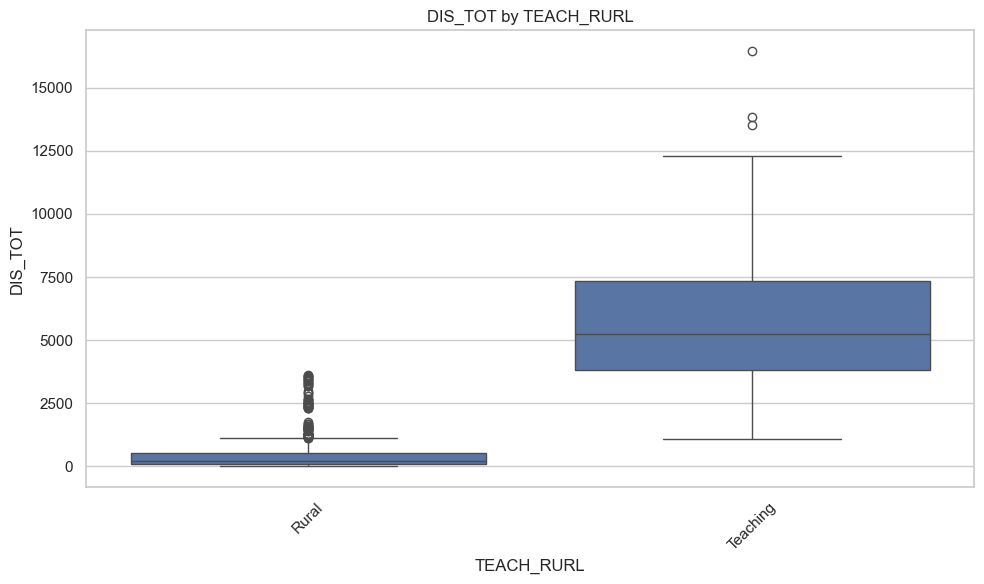

In [19]:
# Compare target distributions by selected categorical variables.
group_features = [
    feature for feature in [
        "TYPE_CNTRL",
        "TYPE_HOSP",
        "TEACH_RURL"
    ]
    if feature in df.columns
]

for feature in group_features:
    plt.figure(figsize=(10, 6))

    order = (
        df.groupby(feature)[TARGET]
          .median()
          .sort_values()
          .index
    )

    sns.boxplot(
        data=df,
        x=feature,
        y=TARGET,
        order=order
    )

    plt.title(f"{TARGET} by {feature}")
    plt.xlabel(feature)
    plt.ylabel(TARGET)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 7. Pearson Correlation Analysis

Pearson correlation measures the strength and direction of a linear relationship between two numerical variables.

The purpose of this section is to:

- Identify numerical variables most strongly associated with 'DIS_TOT'.
- Measure both the direction and strength of linear relationships.
- Support data-driven feature-selection decisions for later modeling.
- Identify highly correlated predictors that may provide similar information.

The analysis focuses on the variables with the strongest absolute Pearson correlations with `DIS_TOT`.

In [20]:
# Pearson correlations with the target.
pearson_target = (
    df[numeric_features]
    .corr(method="pearson")[TARGET]
    .drop(TARGET)
    .dropna()
    .sort_values(key=np.abs, ascending=False)
)

pearson_target_df = pearson_target.to_frame("Pearson_Correlation")

display(pearson_target_df.head(20))

,Pearson_Correlation
DAY_MCAR_MC,0.830
DIS_THRD_MC,0.820
DIS_MCAL_MC,0.815
DIS_MCAR,0.809
DAY_THRD_MC,0.797
GRIP_MCAR_MC,0.793
GRIP_TOT,0.793
DIS_MCAR_MC,0.793
CADJ_MCAR_MC,0.769
NET_MCAR_MC,0.769


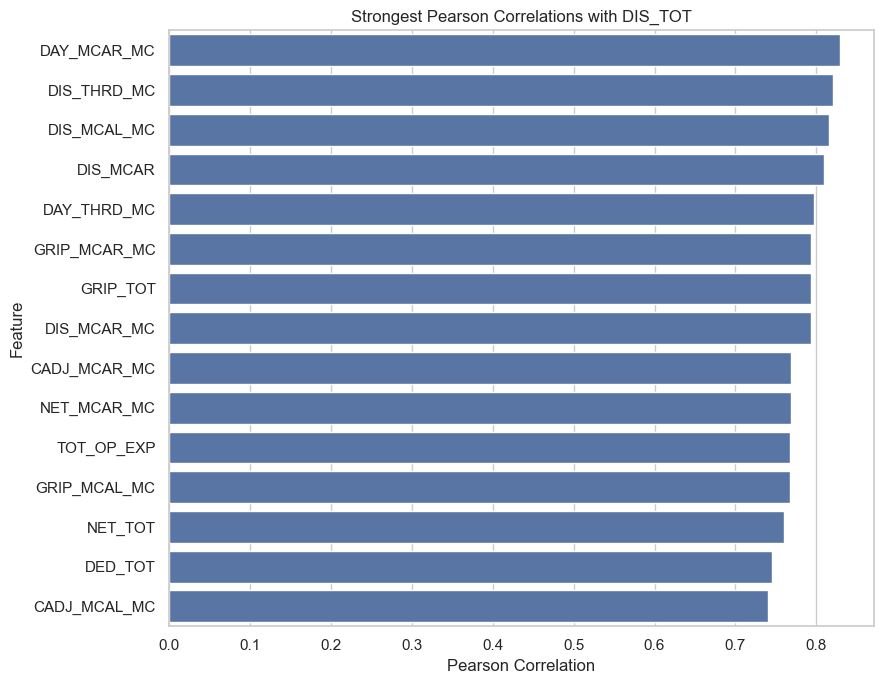

In [21]:
# Visualize the strongest correlations with the target.
top_corr_features = pearson_target_df.head(15).index.tolist()

plt.figure(figsize=(9, 7))

sns.barplot(
    x=pearson_target_df.loc[top_corr_features, "Pearson_Correlation"].values,
    y=top_corr_features
)

plt.title("Strongest Pearson Correlations with DIS_TOT")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

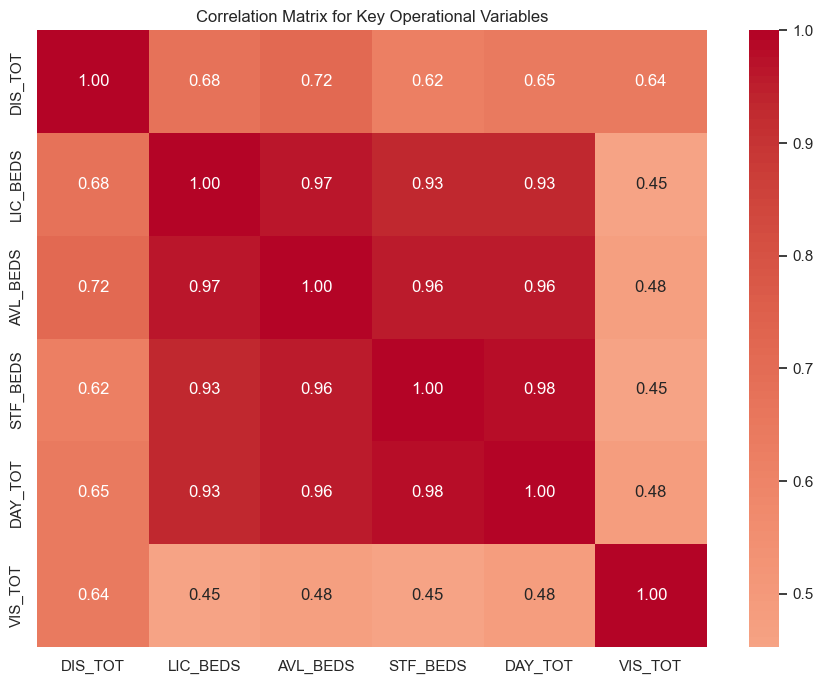

In [22]:
# Correlation heatmap for the main operational variables.
heatmap_features = [
    feature for feature in [
        "DIS_TOT",
        "LIC_BEDS",
        "AVL_BEDS",
        "STF_BEDS",
        "DAY_TOT",
        "VIS_TOT"
    ]
    if feature in df.columns
]

plt.figure(figsize=(9, 7))

sns.heatmap(
    df[heatmap_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix for Key Operational Variables")
plt.tight_layout()
plt.show()

## 8. Multicollinearity

Highly correlated predictors may contain redundant information.

A threshold of `|r| >= 0.80` is used as a screening rule. This does not automatically mean that one variable must be removed; the result is used to inform later feature selection and modeling.

In [23]:
# Predictor-only correlation matrix.
predictor_numeric_features = [
    feature for feature in numeric_features
    if feature != TARGET
]

corr_matrix = df[predictor_numeric_features].corr().abs()

# Keep only the upper triangle to avoid duplicate pairs.
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Absolute_Correlation"
]

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs["Absolute_Correlation"] >= 0.80
    ]
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
)

display(high_corr_pairs.head(30))

,Feature_1,Feature_2,Absolute_Correlation
9666,CURR_MAT_LT_DEBT,CURR_MATURITIES,1.000
9653,TOT_ASSETS,TOT_LIABILITY_AND EQUITY,1.000
9655,CURR_LIABILITIES,TOT_CURR_LIABILITIES,0.995
9563,TOT_PPE,ACCU_DEP_AMORT,0.993
9564,TOT_PPE,NET_TOT_PPE,0.990
8836,NET_TOT,TOT_OP_EXP,0.989
9685,TOT_LT_DEBT,NET_TOT_LT_DEBT,0.987
9446,OTH_CURR_ASSETS,TOT_CURR_ASSETS,0.983
1506,DIS_CNTY_MC,DAY_CNTY_MC,0.980
9339,TOT_OUT_VIS_CC,GROS_OUTPAT_REV_CC,0.980


### Multicollinearity interpretation

Strong correlations are expected among some healthcare operational variables because they measure related aspects of hospital size or utilization.

For example, licensed beds, available beds, staffed beds, patient days, and visits may contain overlapping information. These relationships will be considered during modeling to avoid unnecessary redundancy.

## 9. Statistical Analysis

A single focused hypothesis test is used to investigate whether total discharge volumes differ between lower- and higher-capacity hospitals.

Welch's independent two-sample t-test is used because it does not require the two groups to have equal variances.

In [24]:
# Create two groups using the median available-bed value.
capacity_median = df["AVL_BEDS"].median()

low_capacity = df.loc[
    df["AVL_BEDS"] <= capacity_median,
    TARGET
].dropna()

high_capacity = df.loc[
    df["AVL_BEDS"] > capacity_median,
    TARGET
].dropna()

print("Median AVL_BEDS:", capacity_median)
print("Low-capacity observations:", len(low_capacity))
print("High-capacity observations:", len(high_capacity))

Median AVL_BEDS: 148.0
Low-capacity observations: 4594
High-capacity observations: 4585


In [25]:
# H0: Mean DIS_TOT is equal between the two capacity groups.
# H1: Mean DIS_TOT differs between the two capacity groups.

t_stat, p_value = stats.ttest_ind(
    low_capacity,
    high_capacity,
    equal_var=False
)

print("Welch's t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print(
        "Result: Reject the null hypothesis at the 5% significance level."
    )
else:
    print(
        "Result: Fail to reject the null hypothesis at the 5% significance level."
    )

Welch's t-statistic: -84.30947753538524
p-value: 0.0
Result: Reject the null hypothesis at the 5% significance level.


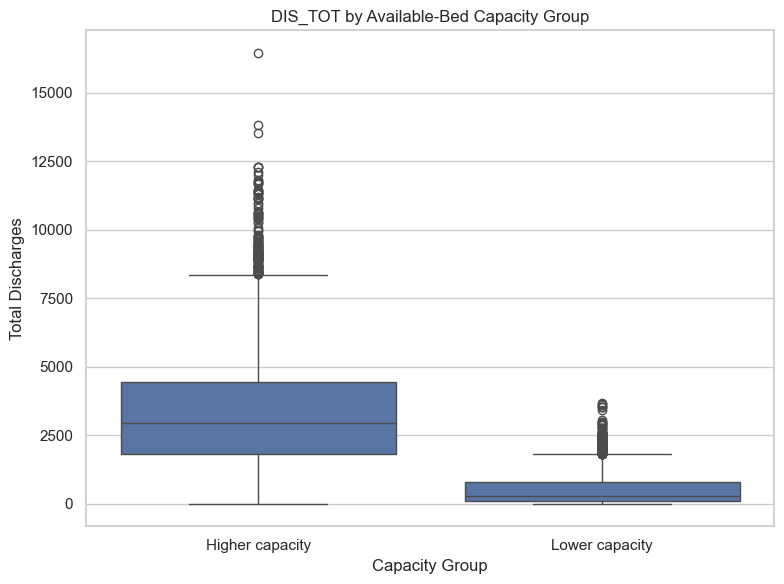

In [26]:
# Visualize the two groups.
test_plot_data = df[["AVL_BEDS", TARGET]].dropna().copy()

test_plot_data["Capacity_Group"] = np.where(
    test_plot_data["AVL_BEDS"] <= capacity_median,
    "Lower capacity",
    "Higher capacity"
)

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=test_plot_data,
    x="Capacity_Group",
    y=TARGET
)

plt.title("DIS_TOT by Available-Bed Capacity Group")
plt.xlabel("Capacity Group")
plt.ylabel("Total Discharges")
plt.tight_layout()
plt.show()

## 10. Missing Data and Outlier Analysis

Missing values are investigated before modeling. Missingness should not automatically be replaced with zero because a missing financial or operational value may represent unavailable reporting rather than an actual zero.

Outliers are also not automatically removed. In hospital data, large observations can represent legitimate differences in hospital size.

In [27]:
# Top 20 features by percentage of missing values.
missing_summary = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .to_frame("Missing_%")
)

display(missing_summary.head(20))

,Missing_%
TEACH_RURL,77.873
CASH,57.185
TOT_LIABILITY_AND EQUITY,57.152
TOT_INV_AND_OTH_ASSETS,57.152
DEP_AMORT_EXP_OPS,57.152
MARKETABLE_SEC,57.152
OTH_CURR_ASSETS,57.152
TOT_CURR_ASSETS,57.152
LIMITED_USE_CASH,57.152
LIMITED_USE_INV,57.152


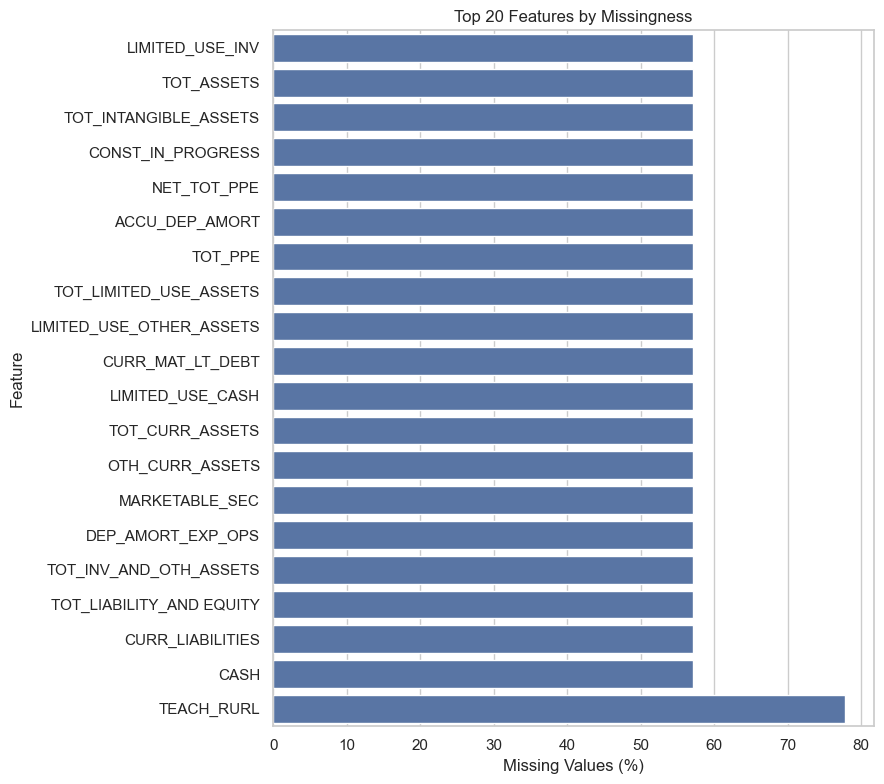

In [28]:
# Simple missingness visualization for the 20 features with the most missing data.
top_missing = missing_summary.head(20).sort_values("Missing_%")

plt.figure(figsize=(9, 8))

sns.barplot(
    x=top_missing["Missing_%"],
    y=top_missing.index
)

plt.title("Top 20 Features by Missingness")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [29]:
# IQR-based outlier summary for numeric features.
outlier_summary = []

for feature in numeric_features:
    series = df[feature].dropna()

    if len(series) == 0:
        continue

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        outlier_count = 0
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_count = (
            (series < lower) |
            (series > upper)
        ).sum()

    outlier_summary.append({
        "Feature": feature,
        "Outlier_Count": outlier_count,
        "Outlier_%": outlier_count / len(series) * 100
    })

outlier_summary = (
    pd.DataFrame(outlier_summary)
    .sort_values("Outlier_%", ascending=False)
)

display(outlier_summary.head(20))

,Feature,Outlier_Count,Outlier_%
68,DISP_855,2266,24.687
127,TOT_LIMITED_USE_ASSETS,938,23.849
84,CAP_TOT,2163,23.565
99,NONOP_REV,1971,21.473
138,TOT_DEF_CREDITS,822,20.900
133,TOT_INTANGIBLE_ASSETS,776,19.730
49,GRIP_INDGNT,1595,17.377
60,GROP_INDGNT,1548,16.865
132,TOT_INV_AND_OTH_ASSETS,645,16.400
120,CASH,638,16.234


### Missing-data decisions

- Variables with little or no missingness can generally be retained for further analysis.
- Variables with substantial missingness should be reviewed individually.
- Structural missingness associated with changes in reporting periods should not automatically be interpreted as zero.
- High-missingness variables may be excluded from the initial model unless there is a strong domain reason to retain them.
- The final imputation strategy will be selected during preprocessing after the candidate feature set is established.

### Outlier decisions

Outliers will not automatically be deleted. Large hospitals can legitimately have much larger discharge, patient-day, financial, and utilization values than smaller facilities. Transformations such as logarithms may be considered during modeling for strongly right-skewed variables.

## 11. Feature Selection

Feature-selection decisions are based on:
- operational relevance,
- relationship with the target,
- missingness,
- redundancy,
- identification/administrative status, and
- potential target leakage.

EDA identifies **candidate features** rather than establishing the final model feature set.

In [30]:
# Candidate features identified from the EDA.
candidate_features = [
    feature for feature in [
        "LIC_BEDS",
        "AVL_BEDS",
        "STF_BEDS",
        "DAY_TOT",
        "VIS_TOT",
        "TYPE_CNTRL",
        "TYPE_HOSP",
        "TEACH_RURL",
        "COUNTY_NAME",
        "HSA"
    ]
    if feature in df.columns
]

print("Candidate features:")
for feature in candidate_features:
    print("-", feature)

Candidate features:
- LIC_BEDS
- AVL_BEDS
- STF_BEDS
- DAY_TOT
- VIS_TOT
- TYPE_CNTRL
- TYPE_HOSP
- TEACH_RURL
- COUNTY_NAME
- HSA


In [31]:
# Variables that should not be used as predictive features.
exclude_features = [
    feature for feature in [
        "FAC_NO",
        "FAC_NAME",
        "PHONE",
        "ADDRESS",
        "CEO",
        "SOURCE_FILE"
    ]
    if feature in df.columns
]

print("Identifier / administrative fields to exclude:")
for feature in exclude_features:
    print("-", feature)

Identifier / administrative fields to exclude:
- FAC_NO
- FAC_NAME
- PHONE
- ADDRESS
- CEO


### Potential target leakage

The following discharge variables should be treated cautiously because they are directly related to `DIS_TOT`:

- `DIS_MCAR`
- `DIS_MCAR_MC`
- `DIS_MCAL`
- `DIS_MCAL_MC`
- `DIS_CNTY`
- `DIS_CNTY_MC`
- `DIS_THRD`
- `DIS_THRD_MC`
- `DIS_INDGNT`
- `DIS_OTH`

These variables may represent components or closely related measures of total discharges. Including them as same-period predictors could allow the model to indirectly observe the target.

Therefore, they should be **excluded from the initial predictive feature set** unless the final prediction design establishes that they are legitimately available before the target is observed.

`DAY_TOT` and `VIS_TOT` also require a prediction-timing decision. If the model forecasts a future quarter, prior-quarter values may be useful predictors. If the model predicts the same quarter, they may introduce leakage.

## 12. Feature Engineering

A simple capacity-related feature is created: the proportion of licensed beds that are currently available.

This feature is only created when `LIC_BEDS` is greater than zero.

In [32]:
df["BED_AVAILABILITY_RATIO"] = np.where(
    df["LIC_BEDS"] > 0,
    df["AVL_BEDS"] / df["LIC_BEDS"],
    np.nan
)

display(
    df["BED_AVAILABILITY_RATIO"].describe()
)

count   9,160.000
mean        0.956
std         0.110
min         0.000
25%         0.977
50%         1.000
75%         1.000
max         1.396
Name: BED_AVAILABILITY_RATIO, dtype: float64

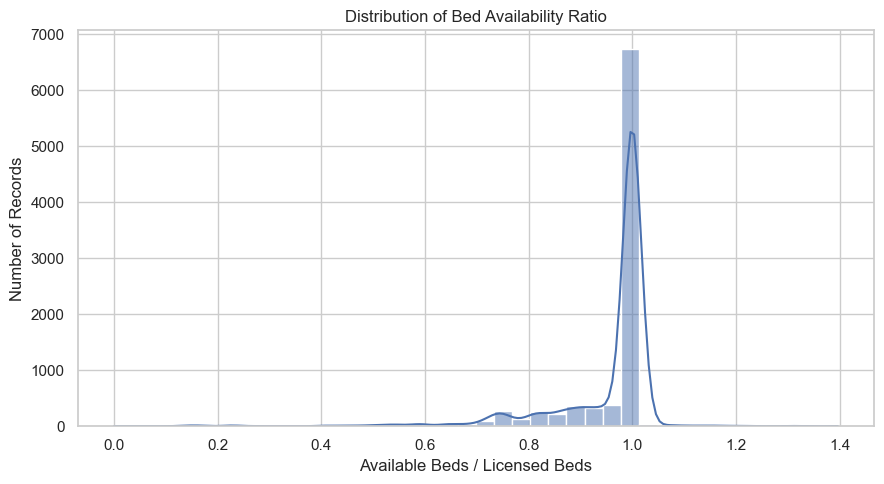

In [33]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="BED_AVAILABILITY_RATIO",
    bins=40,
    kde=True
)

plt.title("Distribution of Bed Availability Ratio")
plt.xlabel("Available Beds / Licensed Beds")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

The bed-availability ratio may provide a more interpretable measure of current capacity than licensed beds alone. Its usefulness should be evaluated during modeling.

## 13. EDA Findings and Data Story

### Main Findings

1. The dataset contains facility-quarter observations across multiple reporting periods, providing a longitudinal view of California healthcare facilities.

2. Hospital capacity varies substantially across facilities, indicating meaningful differences in hospital size and operational scale.

3. `LIC_BEDS`, `AVL_BEDS`, and `STF_BEDS` are directly relevant measures of hospital capacity and show substantial variation across facilities.

4. Discharge and utilization variables have strong positive relationships with `DIS_TOT`, indicating that overall hospital activity and utilization are closely associated with total discharges.

5. Several operational, utilization, and financial variables are highly correlated with one another, indicating potential redundancy and multicollinearity among predictors.

6. `DIS_TOT` is right-skewed and includes large values associated with high-volume hospitals. These extreme observations should not automatically be considered errors or removed.

7. Missingness varies substantially across attributes and reporting periods. These patterns should be considered during preprocessing and feature selection.

8. Identifier and contact fields do not provide meaningful predictive information and should not be included as model features.

9. Discharge component variables require careful consideration because variables that directly represent components of `DIS_TOT` may introduce target leakage if used as predictors.

10. The exploratory analysis supports further evaluation of engineered capacity measures, such as a bed-availability ratio, during feature engineering and model development.

### Overall EDA Conclusion

Overall, the EDA shows that **hospital capacity, utilization, and operational activity are strongly related to total discharges**. At the same time, the dataset contains important considerations—including skewness, missing values, multicollinearity, and potential target leakage—that must be addressed before predictive modeling. These findings provide the basis for the next stages of **preprocessing, feature selection, feature engineering, and model development**.
